## Imports and setup

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [39]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
LEGIT_COLOR, FRAUD_COLOR = "#2a78d6", "#eb6834"

### Objetivos:
1. **Avaliar o modelo atual (champion)** - medir a performance preditiva do modelo em produção a partir dos scores do dataset, justificando quais métricas são mais adequadas para um problema de fraude desbalanceado e por quê. *(Case 1a)*
2. **Treinar um modelo desafiante (Challenger)** capaz de substituir o modelo vigente na discriminação entre transações fraudulentas e legítimas:
    - justificar as técnicas de pré-processamento e o algoritmo escolhidos; *(Case 2a)*
    - comparar os dois modelos no mesmo período de teste (out-of-time), com as mesmas métricas e uma checagem de consistência dia a dia. *(Case 2b)*
3. **Definir o ponto de corte que maximiza o lucro** - considerando comissão de 10% sobre cada transação legítima aprovada e perda de 100% do valor de cada fraude aprovada. *(Case 2c)*

A ideia inicial é utilizar um algoritmo de Boost (LightGBM) para o challenger, visto que este se adequa a features categóricas

## Step 1 - EDA

In [40]:
df  =  pd.read_csv(  'https://hr-projects-assets-prod.s3.amazonaws.com/3st1g8gm56o/ed953178414189325c980dc1a9214b97/data.csv'  ) 

In [41]:
df["fecha"] = pd.to_datetime(df["fecha"])

In [42]:
df.head()

,a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.7685,94436.24,20.0,0.444828,1.0,BR,5,Máquininha Corta Barba Cabelo Peito Perna Pelo...,cat_8d714cd,0.883598,240.0,102.0,1,NaN,N,2020-03-27 11:51:16,5.64,66,0
1,4,0.7550,9258.50,1.0,0.000000,33.0,BR,0,Avental Descartavel Manga Longa - 50 Un. Tnt ...,cat_64b574b,0.376019,4008.0,0.0,1,Y,N,2020-04-15 19:58:08,124.71,72,0
2,4,0.7455,242549.09,3.0,0.000000,19.0,AR,23,Bicicleta Mountain Fire Bird Rodado 29 Alumini...,cat_e9110c5,0.516368,1779.0,77.0,1,NaN,N,2020-03-25 18:13:38,339.32,95,0
3,4,0.7631,18923.90,50.0,0.482385,18.0,BR,23,Caneta Delineador Carimbo Olho Gatinho Longo 2...,cat_d06e653,0.154036,1704.0,1147.0,1,NaN,Y,2020-04-16 16:03:10,3.54,2,0
4,2,0.7315,5728.68,15.0,0.000000,1.0,BR,2,Resident Evil Operation Raccoon City Ps3,cat_6c4cfdc,0.855798,1025.0,150.0,1,NaN,N,2020-04-02 10:24:45,3.53,76,0


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   a       150000 non-null  int64         
 1   b       137016 non-null  float64       
 2   c       137016 non-null  float64       
 3   d       149635 non-null  float64       
 4   e       150000 non-null  float64       
 5   f       149989 non-null  float64       
 6   g       149806 non-null  str           
 7   h       150000 non-null  int64         
 8   i       150000 non-null  str           
 9   j       150000 non-null  str           
 10  k       150000 non-null  float64       
 11  l       149989 non-null  float64       
 12  m       149635 non-null  float64       
 13  n       150000 non-null  int64         
 14  o       41143 non-null   str           
 15  p       150000 non-null  str           
 16  fecha   150000 non-null  datetime64[us]
 17  monto   150000 non-null  float64       


In [44]:
df.select_dtypes(include=["int64", "float64"]).describe()

,a,b,c,d,e,f,h,k,l,m,n,monto,score,fraude
count,150000.000000,137016.000000,1.370160e+05,149635.000000,150000.000000,149989.000000,150000.000000,150000.000000,149989.000000,149635.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,3.705407,0.728115,2.604451e+05,21.677669,0.220641,51.169352,14.193513,0.497532,2305.409403,299.969579,0.902353,43.523134,48.066240,0.050000
std,0.753206,0.132943,8.464361e+05,20.062146,2.434995,709.472904,14.161216,0.288348,1712.379601,321.075806,0.296837,91.557888,28.995122,0.217946
min,1.000000,0.000000,1.600000e-01,0.000000,0.000000,-5.000000,0.000000,0.000004,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000
25%,4.000000,0.678400,9.679915e+03,2.000000,0.000000,1.000000,3.000000,0.246819,910.000000,42.000000,1.000000,9.380000,23.000000,0.000000
50%,4.000000,0.755500,4.371165e+04,14.000000,0.104875,8.000000,9.000000,0.495990,1937.000000,193.000000,1.000000,20.610000,48.000000,0.000000
75%,4.000000,0.806500,1.454436e+05,50.000000,0.282938,33.000000,21.000000,0.746508,3445.000000,459.000000,1.000000,40.692500,73.000000,0.000000
max,4.000000,1.000000,1.387874e+07,50.000000,833.333333,145274.000000,58.000000,0.999995,7544.000000,2225.000000,1.000000,3696.350000,100.000000,1.000000


#### Check target distribution

In [45]:
df["fraude"].value_counts()

fraude
0    142500
1      7500
Name: count, dtype: int64

In [46]:
proportions = df["fraude"].value_counts(normalize=True) * 100
print(f"Transações não fraudulentas: {proportions.get(0, 0):.2f}%\nFraudes: {proportions.get(1, 0):.2f}%")

Transações não fraudulentas: 95.00%
Fraudes: 5.00%


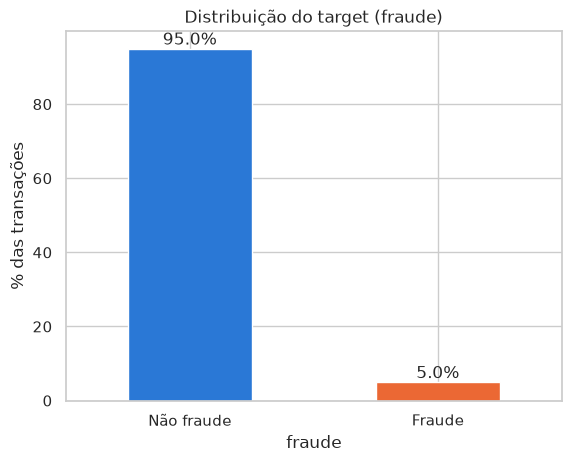

In [47]:
ax = proportions.plot(kind="bar", color=[LEGIT_COLOR, FRAUD_COLOR])
ax.bar_label(ax.containers[0], fmt="%.1f%%")
ax.set_xticklabels(["Não fraude", "Fraude"], rotation=0)
ax.set(ylabel="% das transações", title="Distribuição do target (fraude)")
plt.show()

### Validação de nulos

In [48]:
df.isnull().sum()

a              0
b          12984
c          12984
d            365
e              0
f             11
g            194
h              0
i              0
j              0
k              0
l             11
m            365
n              0
o         108857
p              0
fecha          0
monto          0
score          0
fraude         0
dtype: int64

*Análise de nulos em função do tempo (separado por semana)*

In [49]:
colunas_com_nulo = ["b", "c", "d", "m", "g", "o"]

nulos_semana = df.groupby(pd.Grouper(key="fecha", freq="W-SUN"))[colunas_com_nulo].apply(
    lambda w: w.isnull().mean() * 100
)
nulos_semana.round(1)

,b,c,d,m,g,o
fecha,,,,,,
2020-03-08,0.8,0.8,0.1,0.1,0.0,71.5
2020-03-15,47.9,47.9,0.3,0.3,0.0,72.7
2020-03-22,1.1,1.1,0.3,0.3,0.0,72.6
2020-03-29,1.1,1.1,0.5,0.5,0.1,72.5
2020-04-05,1.0,1.0,0.1,0.1,0.2,72.0
2020-04-12,0.8,0.8,0.3,0.3,0.2,72.6
2020-04-19,0.9,0.9,0.1,0.1,0.2,72.6
2020-04-26,0.9,0.9,0.1,0.1,0.1,73.2


Observação: Há uma grande quantidade de nulos para b e c na segunda semana (2020-03-15), isso se torna mais relevante visto que o volume de nulos em ambas as features é o mesmo. Isso pode indicar problemas nos dados que serão alimentados ao modelo

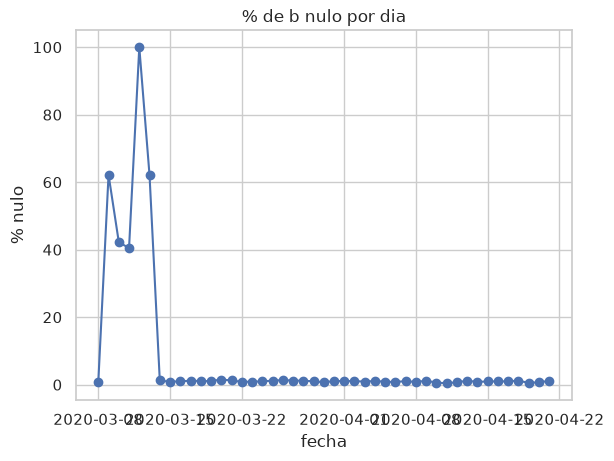

,transacoes,pct_b_nulo,pct_c_nulo
fecha,,,
2020-03-08,2838,0.8,0.8
2020-03-09,4173,62.2,62.2
2020-03-10,4105,42.3,42.3
2020-03-11,3899,40.4,40.4
2020-03-12,3787,100.0,100.0
2020-03-13,3229,62.0,62.0
2020-03-14,2560,1.2,1.2
2020-03-15,2770,0.9,0.9
2020-03-16,4202,1.0,1.0


In [50]:
nulos_dia = df.groupby(df["fecha"].dt.date).agg(
    transacoes=("b", "size"),
    pct_b_nulo=("b", lambda s: s.isnull().mean() * 100),
    pct_c_nulo=("c", lambda s: s.isnull().mean() * 100),
)

ax = nulos_dia["pct_b_nulo"].plot(marker="o", title="% de b nulo por dia")
ax.set_ylabel("% nulo")
plt.show()

nulos_dia.round(1).head(14)

Analisando o gráfico e a tabela vemos que esse problema ocorre nos dias 09 a 13, com um grande agravante no dia 12. Isso indica que algo pode ter ocorrido nessa semana que pode ter afetado os dados para essas features em específico. Após esse período o valor cai para menos de 1%

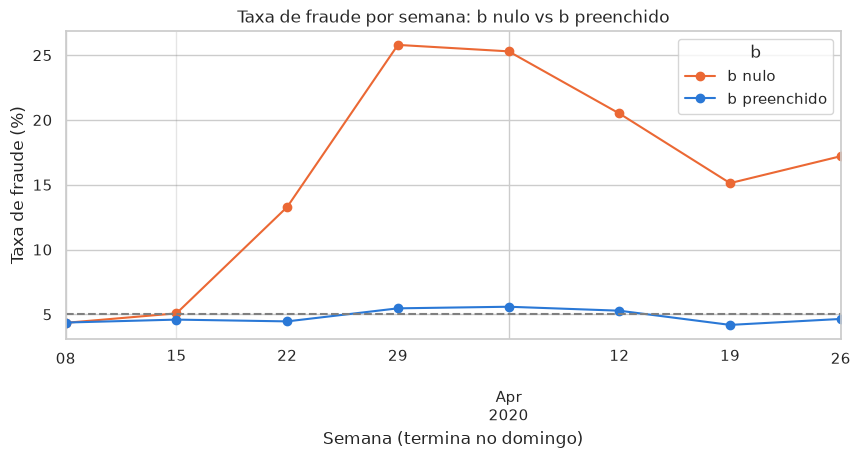

taxa de fraude (%)              transações             
b                      b nulo b preenchido     b nulo b preenchido
fecha                                                             
2020-03-08                4.3          4.4         23         2815
2020-03-15                5.1          4.6      11753        12770
2020-03-22               13.3          4.5        286        24913
2020-03-29               25.8          5.5        221        19848
2020-04-05               25.3          5.6        170        17264
2020-04-12               20.5          5.3        200        24243
2020-04-19               15.1          4.2        238        25094
2020-04-26               17.2          4.6         93        10069

In [51]:
semana = pd.Grouper(key="fecha", freq="W-SUN")
b_status = df["b"].isnull().map({True: "b nulo", False: "b preenchido"})

fraude_b = df.groupby([semana, b_status])["fraude"].mean().unstack() * 100
volume_b = df.groupby([semana, b_status]).size().unstack()

ax = fraude_b.plot(marker="o", color={"b preenchido": LEGIT_COLOR, "b nulo": FRAUD_COLOR}, figsize=(10, 4))
ax.axhline(5, color="gray", linestyle="--")  # média geral
ax.axvspan(pd.Timestamp("2020-03-09"), pd.Timestamp("2020-03-15"), color="gray", alpha=0.2)  # semana do incidente
ax.set(title="Taxa de fraude por semana: b nulo vs b preenchido", xlabel="Semana (termina no domingo)", ylabel="Taxa de fraude (%)")
plt.show()

pd.concat([fraude_b.round(1), volume_b], axis=1, keys=["taxa de fraude (%)", "transações"])


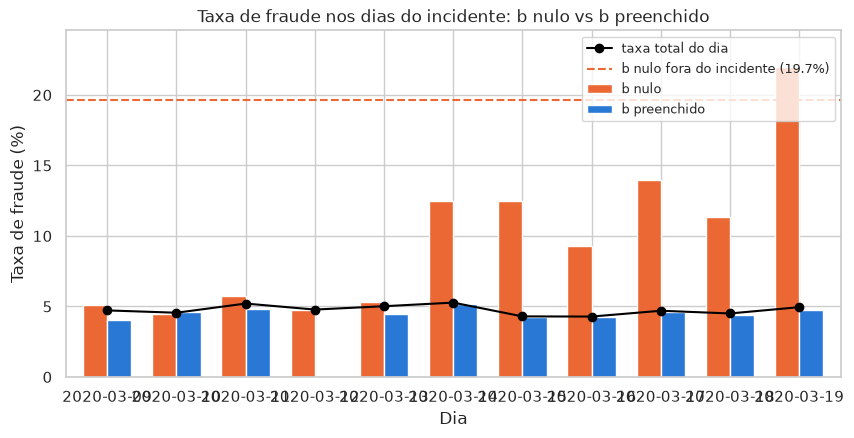

taxa de fraude (%)                           transações  \
b                      b nulo b preenchido total do dia     b nulo   
fecha                                                                
2020-03-09                5.1          4.1          4.7     2595.0   
2020-03-10                4.5          4.6          4.6     1735.0   
2020-03-11                5.8          4.8          5.2     1577.0   
2020-03-12                4.8          NaN          4.8     3787.0   
2020-03-13                5.3          4.5          5.0     2003.0   
2020-03-14               12.5          5.2          5.3       32.0   
2020-03-15               12.5          4.2          4.3       24.0   
2020-03-16                9.3          4.2          4.3       43.0   
2020-03-17               14.0          4.6          4.7       50.0   
2020-03-18               11.4          4.4          4.5       44.0   
2020-03-19               22.0          4.8          4.9       41.0   

                         
b          b preenchido  
fecha                    
2020-03-09       1578.0  
2020-03-10       2370.0  
2020-03-11       2322.0  
2020-03-12          NaN  
2020-03-13       1226.0  
2020-03-14       2528.0  
2020-03-15       2746.0  
2020-03-16       4159.0  
2020-03-17       4230.0  
2020-03-18       3997.0  
2020-03-19       3858.0

In [53]:
# Incidente de coleta (09/03 a 13/03), encontrado no gráfico diário de nulos, e os dias seguintes para comparação
incidente = df["fecha"].between("2020-03-09", "2020-03-14", inclusive="left")
dias = df[df["fecha"].between("2020-03-09", "2020-03-20", inclusive="left")]

b_status = dias["b"].isnull().map({True: "b nulo", False: "b preenchido"})
taxa_dia = dias.groupby([dias["fecha"].dt.date, b_status])["fraude"].mean().unstack() * 100
taxa_dia["total do dia"] = dias.groupby(dias["fecha"].dt.date)["fraude"].mean() * 100
volume_dia = dias.groupby([dias["fecha"].dt.date, b_status]).size().unstack()

# Referência: taxa de fraude de b nulo nos dias normais
fora = df[~incidente]
taxa_nulo_fora = fora.loc[fora["b"].isnull(), "fraude"].mean() * 100

ax = taxa_dia[["b nulo", "b preenchido"]].plot(kind="bar", color=[FRAUD_COLOR, LEGIT_COLOR], width=0.7, figsize=(10, 4.5))
ax.plot(range(len(taxa_dia)), taxa_dia["total do dia"], color="black", marker="o", label="taxa total do dia")
ax.axhline(taxa_nulo_fora, color=FRAUD_COLOR, linestyle="--", label=f"b nulo fora do incidente ({taxa_nulo_fora:.1f}%)")
ax.set(title="Taxa de fraude no incidente (09 a 13/03) e nos dias seguintes: b nulo vs b preenchido", xlabel="Dia", ylabel="Taxa de fraude (%)",
       ylim=(0, max(taxa_nulo_fora, taxa_dia.max().max()) * 1.2))
ax.legend(fontsize=9, loc="upper left")
ax.set_xticklabels([d.strftime("%d/%m") for d in taxa_dia.index], rotation=0)
plt.show()

pd.concat([taxa_dia.round(1), volume_dia], axis=1, keys=["taxa de fraude (%)", "transações"])

Nos dias do incidente (09 a 13/03), a taxa de fraude com `b` nulo (de 4,5% a 5,8%) fica no mesmo nível da taxa com `b` preenchido (de 4,1% a 4,8%) e da taxa total de cada dia (de 4,6% a 5,2%). Em 12/03 todas as transações tiveram `b` nulo, por isso não há barra azul nesse dia. Nesses dias o nulo foi causado pela falha de coleta e não diz nada sobre fraude.

Nos dias seguintes (14 a 19/03) o volume de `b` nulo volta ao normal, cerca de 40 transações por dia, e a taxa de fraude delas sobe para 9% a 22% (13,7% no período), contra 4,5% com `b` preenchido. Fora do incidente, portanto, o nulo de `b` ainda indica mais risco, mas atinge um grupo muito pequeno (cerca de 1% das transações).

**Decisão:** `b` segue no modelo com os nulos, que o LightGBM trata nativamente. Não criamos uma flag separada para o nulo de `b`: o grupo é pequeno (cerca de 1% das transações fora do incidente), e num teste a flag respondeu por menos de 1% da importância do modelo. Ela adicionaria uma regra de datas para manter (excluir a janela do incidente) com ganho mínimo.

#### Nulos: taxa de fraude quando o valor é nulo vs preenchido
A quantidade de nulos sozinha não decide se uma coluna sai. O que importa é se o nulo diz algo sobre fraude: se a taxa muda muito entre nulo e preenchido, o nulo é informativo e vira sinal, em vez de ser imputado ou descartado.

In [15]:
null_cols = df.columns[df.isnull().any()]

null_table = pd.DataFrame({
    "% nulos": df[null_cols].isnull().mean() * 100,
    "fraude se nulo": {c: df.loc[df[c].isnull(), "fraude"].mean() * 100 for c in null_cols},
    "fraude não nulo": {c: df.loc[df[c].notnull(), "fraude"].mean() * 100 for c in null_cols},
})

null_table.sort_values("% nulos", ascending=False).round(2)

,% nulos,fraude se nulo,fraude não nulo
o,72.57,2.05,12.79
b,8.66,6.38,4.87
c,8.66,6.38,4.87
d,0.24,7.95,4.99
m,0.24,7.95,4.99
g,0.13,7.73,5.00
f,0.01,0.00,5.00
l,0.01,0.00,5.00


### Análise da feature 'o' (maior indice de nulos)

In [16]:
nulos_o = df["o"].fillna("nulo")

tabela_o = df.groupby(nulos_o)["fraude"].agg(transacoes="size", fraudes="sum")
tabela_o["taxa_fraude_%"] = tabela_o["fraudes"] / tabela_o["transacoes"] * 100
tabela_o["%_transacoes"] = tabela_o["transacoes"] / tabela_o["transacoes"].sum() * 100
tabela_o["%_fraudes"] = tabela_o["fraudes"] / tabela_o["fraudes"].sum() * 100
tabela_o.round(1)

,transacoes,fraudes,taxa_fraude_%,%_transacoes,%_fraudes
o,,,,,
N,17052,3709,21.8,11.4,49.5
Y,24091,1554,6.5,16.1,20.7
nulo,108857,2237,2.1,72.6,29.8


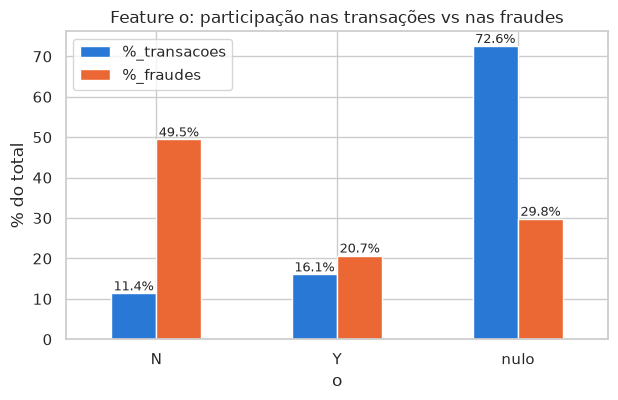

In [17]:
ax = tabela_o[["%_transacoes", "%_fraudes"]].plot(kind="bar", color=[LEGIT_COLOR, FRAUD_COLOR], figsize=(7, 4))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)
ax.set(title="Feature o: participação nas transações vs nas fraudes", xlabel="o", ylabel="% do total")
plt.xticks(rotation=0)
plt.show()


In [18]:
nulos_imputados = df["o"].fillna(df["o"].mode()[0])  # valor mais comum entre os preenchidos: "Y"

comparacao = pd.concat({
    "% fraude mantendo nulo": df.groupby(nulos_o)["fraude"].mean() * 100,
    "% fraude nulo imputado com 'Y'": df.groupby(nulos_imputados)["fraude"].mean() * 100,
}, axis=1)
comparacao.round(1)

,% fraude mantendo nulo,% fraude nulo imputado com 'Y'
o,,
N,21.8,21.8
Y,6.5,2.9
nulo,2.1,NaN


Caso optasse por imputar o valor, a taxa de fraude relacionada a Y cairia para 2,9%, assim perdemos boa parte da explicabilidade da categoria. Assim mantem-se esta categoria para o treinamento do modelo, porém, serão feitos dois testes com e sem a presença dela para verificar sua importância ao modelo.

## Análise de Target (fraude)

### Distribuição de fraude por semana

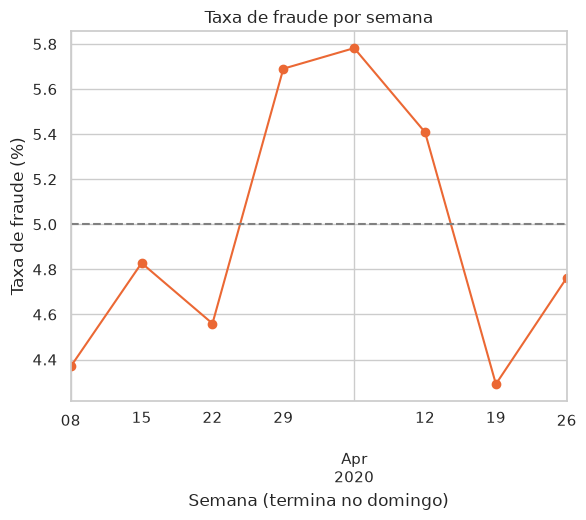

,transacoes,taxa_fraude
fecha,,
2020-03-08,2838,4.37
2020-03-15,24523,4.83
2020-03-22,25199,4.56
2020-03-29,20069,5.69
2020-04-05,17434,5.78
2020-04-12,24443,5.41
2020-04-19,25332,4.29
2020-04-26,10162,4.76


In [19]:
weekly = df.groupby(pd.Grouper(key="fecha", freq="W-SUN")).agg(
    transacoes=("fraude", "size"),
    taxa_fraude=("fraude", "mean"),
)
weekly["taxa_fraude"] *= 100

ax = weekly["taxa_fraude"].plot(marker="o", color=FRAUD_COLOR)
ax.axhline(df["fraude"].mean() * 100, color="gray", linestyle="--")  # média geral (5%)
ax.set(title="Taxa de fraude por semana", xlabel="Semana (termina no domingo)", ylabel="Taxa de fraude (%)")
plt.show()

weekly.round(2)

**Leitura:** a taxa de fraude semanal varia entre ~4,4% e ~5,8%. O pico fica no fim de março e início de abril (início das quarentenas da COVID), e as semanas mais recentes (período de Test) têm a menor taxa. Parte dessa queda pode ser maturidade do rótulo: fraudes recentes podem ainda não ter sido confirmadas quando os dados foram extraídos. As semanas das pontas têm poucos dias (08/03 e 20–21/04) e são menos confiáveis.

#### Distribuição de valor: fraude vs não fraude observando o valor da transação (monto)

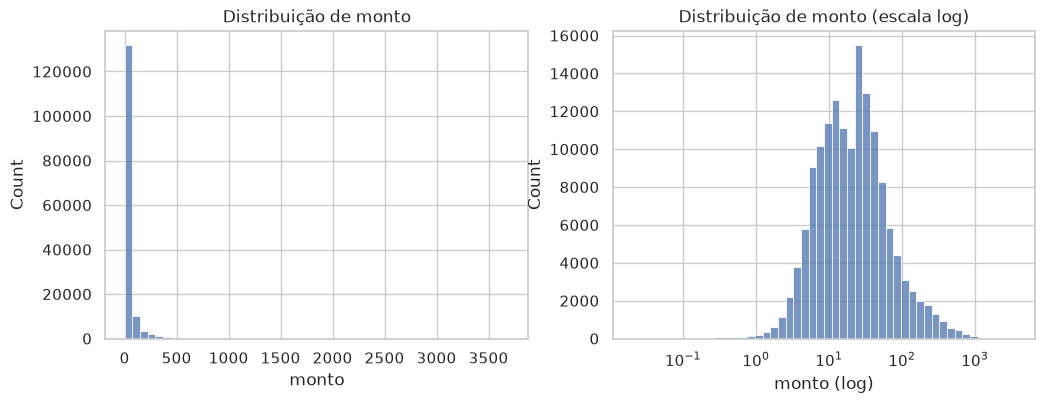

count    150000.00
mean         43.52
std          91.56
min           0.02
25%           9.38
50%          20.61
75%          40.69
max        3696.35
Name: monto, dtype: float64

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["monto"], bins=50, ax=ax1)
ax1.set(title="Distribuição de monto", xlabel="monto")

sns.histplot(df["monto"], bins=50, log_scale=True, ax=ax2)
ax2.set(title="Distribuição de monto (escala log)", xlabel="monto (log)")

plt.show()

df["monto"].describe().round(2)

`monto` é muito assimétrico (média de ~43, mediana de ~20 e máximo ~3.700), então usamos escala log. Podemos ver que tem-se uma cauda longa em que majoritariamente os valores de transação estão concentrados à esquerda do histograma de distribuição em escala comum. 

No eixo log, cada marca multiplica o valor por 10. A maior parte das transações fica entre 10 e 40 (mediana ≈ 20). As duas classes se sobrepõem nessa faixa, mas acima de ~100 a curva de fraude fica acima da de não fraude: as fraudes se concentram nos valores altos, o que explica elas serem 5% das transações e 8,4% do valor total.

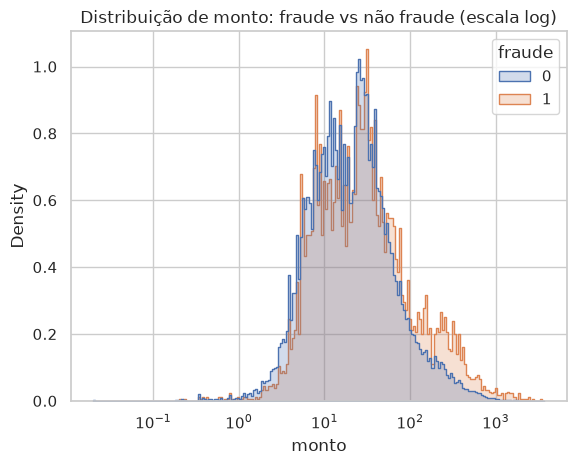

,count,mean,std,min,50%,95%,99%,max
fraude,,,,,,,,
0,142500.0,41.97,85.71,0.02,20.18,151.10,397.66,3696.35
1,7500.0,72.97,164.84,0.21,25.87,313.66,736.72,3424.81


In [21]:
sns.histplot(data=df, x="monto", hue="fraude", log_scale=True,
             stat="density", common_norm=False, element="step")
plt.title("Distribuição de monto: fraude vs não fraude (escala log)")
plt.show()

df.groupby("fraude")["monto"].describe(percentiles=[0.5, 0.95, 0.99]).round(2)

## Taxa de fraude por hora do dia

A suspeita é que as fraudes possam estar concentradas em transações que ocorrem fora do horário comercial. Esse é um comportamento que pode ser esperado devido ao ritmo desacelerado da madrugada em que a vitima está ausente do celular/computador, há menos monitoramento ativo e revisão manual.

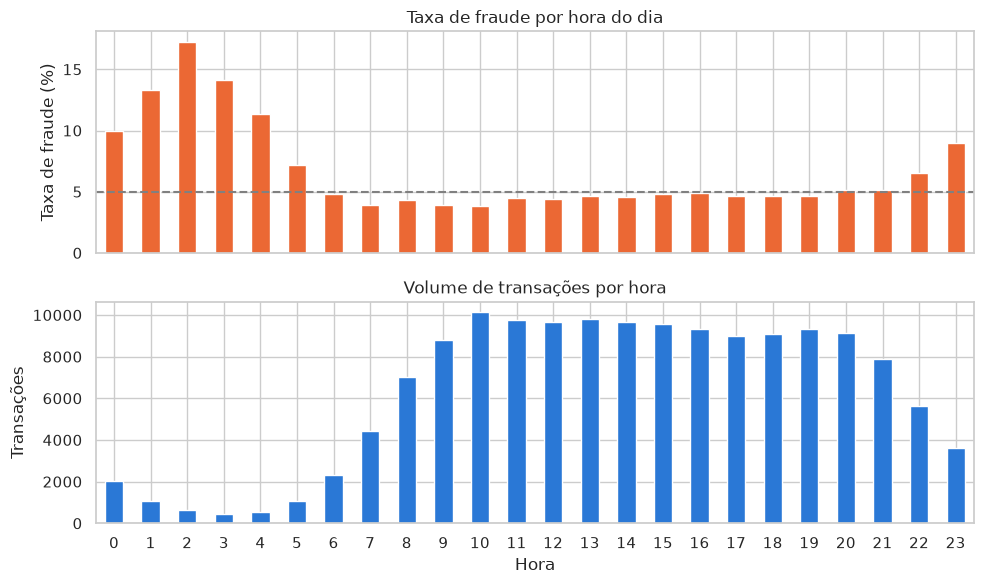

In [22]:
df["hora"] = df["fecha"].dt.hour
by_hour = df.groupby("hora")["fraude"].agg(taxa="mean", transacoes="size")
by_hour["taxa"] *= 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
by_hour["taxa"].plot(kind="bar", color=FRAUD_COLOR, ax=ax1)
ax1.axhline(5, color="gray", linestyle="--")  # média geral
ax1.set(title="Taxa de fraude por hora do dia", ylabel="Taxa de fraude (%)")

by_hour["transacoes"].plot(kind="bar", color=LEGIT_COLOR, ax=ax2)
ax2.set(title="Volume de transações por hora", xlabel="Hora", ylabel="Transações")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [23]:
df["periodo"] = pd.cut(df["hora"], bins=[-1, 5, 11, 17, 23],
                       labels=["madrugada (0-5h)", "manhã (6-11h)", "tarde (12-17h)", "noite (18-23h)"])

periodo = df.groupby("periodo", observed=True)["fraude"].agg(taxa="mean", transacoes="size", fraudes="sum")
periodo["taxa"] *= 100
periodo["% transações"] = periodo["transacoes"] / len(df) * 100
periodo["% fraudes"] = periodo["fraudes"] / df["fraude"].sum() * 100
periodo.round(1)

,taxa,transacoes,fraudes,% transações,% fraudes
periodo,,,,,
madrugada (0-5h),11.3,5814,657,3.9,8.8
manhã (6-11h),4.1,42455,1759,28.3,23.5
tarde (12-17h),4.7,57055,2664,38.0,35.5
noite (18-23h),5.4,44676,2420,29.8,32.3


Conclusões
- No período das 22h até as 6h o número de transações diminui, porém a taxa de fraudes de acordo com o volume de transações mais que dobra para os mesmos horários.
- A madrugada (0–5h) tem 11,3% de fraude, mais que o dobro da média. Tem apenas 3,9% das transações, mas compõe 8,8% das fraudes com pico às 2h (17,2%).
- O padrão aparece em BR e em AR, então não é efeito do mix de países.
- O valor mediano total transacionado das transações da madrugada não é maior que no resto do dia: é o horário em si que apresenta uma taxa de fraudes maior.
- Ideia para o feature engineering: Usar a hora do dia como feature no Step 4, dado que o padrão de fraude se apresenta mais promissor na madrugada

#### Participação da fraude: por quantidade vs por `monto`
Fraudes são 5% das transações, mas pesam mais no valor total, porque se concentram em valores mais altos. É o valor que define o Profit, não a quantidade.

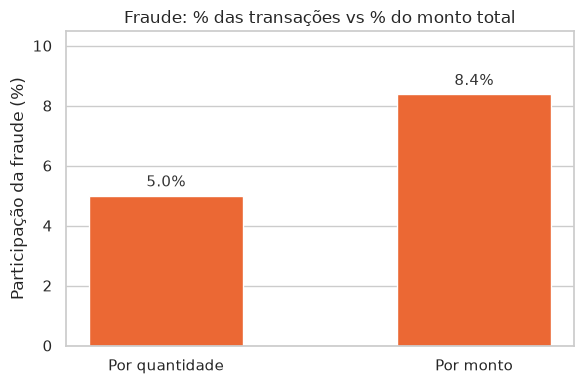

Por quantidade    5.00
Por monto         8.38
dtype: float64

In [24]:
is_fraud = df["fraude"] == 1
fraud_share = pd.Series({
    "Por quantidade": is_fraud.mean(),
    "Por monto": df.loc[is_fraud, "monto"].sum() / df["monto"].sum(),
}) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(fraud_share.index, fraud_share.values, color=FRAUD_COLOR, width=0.5)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in fraud_share], padding=4, fontsize=11, color="#333333")
ax.set(ylabel="Participação da fraude (%)", ylim=(0, fraud_share.max() * 1.25),
       title="Fraude: % das transações vs % do monto total")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

fraud_share.round(2)

### Taxa de fraude das variáveis numéricas
Cada variável é dividida em decis, e para cada faixa calculamos a taxa de fraude.
- Linha plana perto da média (5%) = sem sinal.
- Linha subindo ou descendo = a variável separa fraude de não fraude.
- Formato em U ou salto = sinal não linear, que um modelo de árvore captura melhor que uma regressão logística.

O título traz o KS da variável sozinha (0 = sem separação; acima de ~0,8 seria suspeita de vazamento). Linhas com nulo ficam de fora; o nulo foi analisado na tabela de nulos.

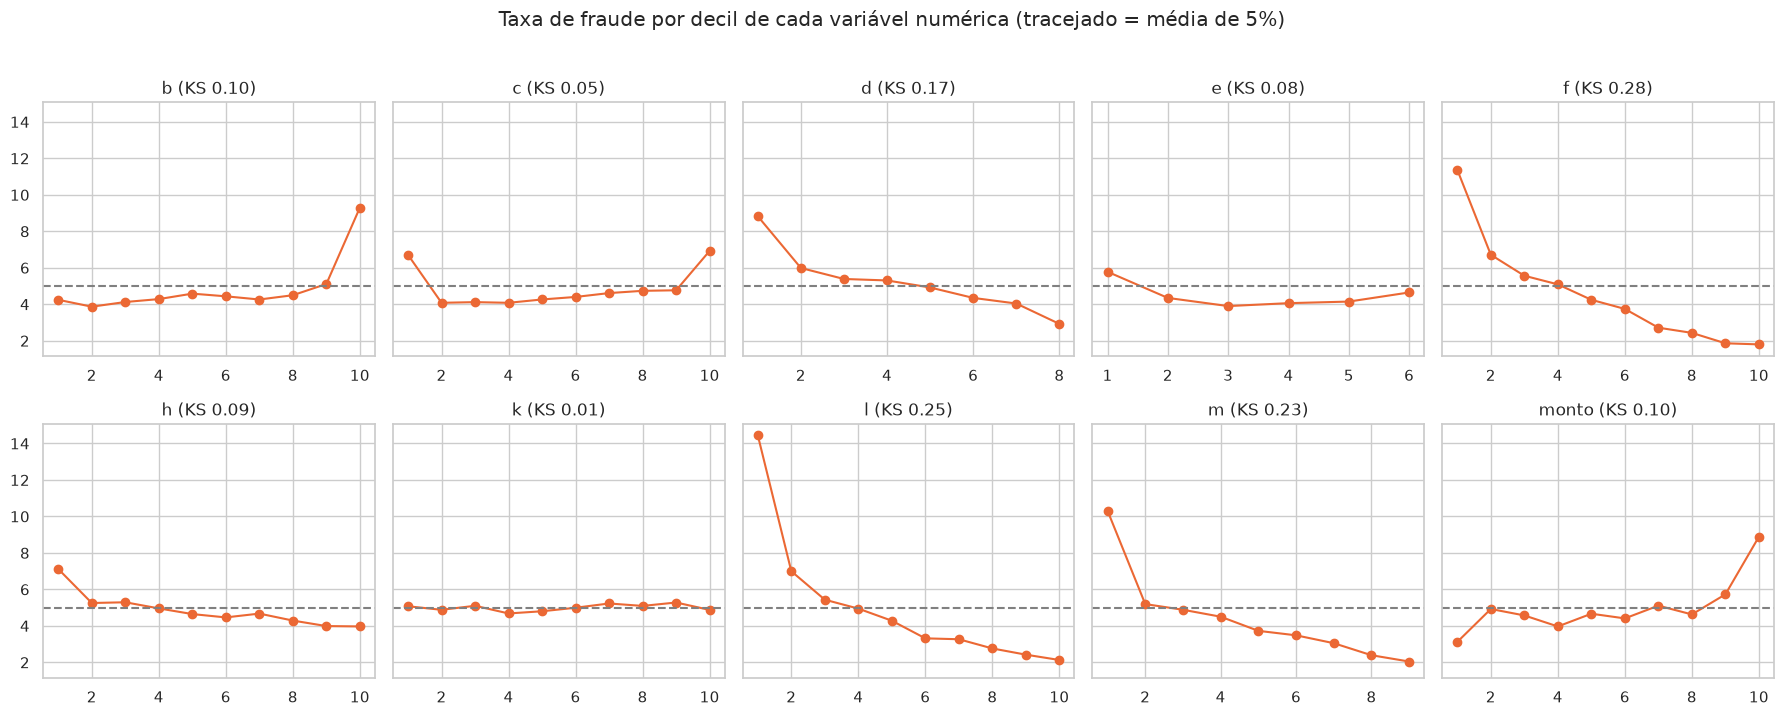

In [25]:
from scipy.stats import ks_2samp

numeric_cols = ["b", "c", "d", "e", "f", "h", "k", "l", "m", "monto"]
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)

for ax, col in zip(axes.flatten(), numeric_cols):
    data = df[[col, "fraude"]].dropna()

    # Taxa de fraude em cada decil da variável
    rate = data.groupby(pd.qcut(data[col], 10, duplicates="drop"), observed=True)["fraude"].mean() * 100
    ks = ks_2samp(data.loc[data["fraude"] == 1, col], data.loc[data["fraude"] == 0, col]).statistic

    ax.plot(range(1, len(rate) + 1), rate.values, marker="o", color=FRAUD_COLOR)
    ax.axhline(5, color="gray", linestyle="--")  # média geral
    ax.set_title(f"{col} (KS {ks:.2f})")

fig.suptitle("Taxa de fraude por decil de cada variável numérica (tracejado = média de 5%)", y=1.02)
plt.tight_layout()
plt.show()

 - *f, l, m* apresentam uma separação mais forte (KS 0,23–0,28): a fraude se concentra nos menores valores. *d* tem uma separação moderada (0,17) e *h*  acaba sendo fraca (0,09), com a mesma tendência.
 - *b* e monto têm KS baixo (~0,10), mas o sinal está concentrado no topo: nos maiores valores a taxa de fraude sobe para ~9%. O KS é baixo porque só ~10–20% das linhas diferem.
 - *c* tem KS baixo (0,05), com forma de U: as duas pontas têm mais fraude. → removida: sinal fraco, e o nulo de *c* é idêntico ao de *b*
 - *e* é fraca (KS 0,08), sem padrão claro entre os decis → removida.
 - *k*  não tem sinal (taxa plana, KS 0,01) → removida.
 - Nenhuma variável passa de KS 0,8, então não há sinal de leakage.
 - Essas leituras são de cada variável sozinha; a importância no modelo será confirmada na feature evaluation.

### Análise do KS por decil das features

In [26]:
def ks_por_decil(data, col, maior_e_pior=False):
    data = data[[col, "fraude"]].dropna()
    tabela = data.groupby(pd.qcut(data[col], 10, duplicates="drop"), observed=True)["fraude"].agg(
        fraudes="sum", total="size")
    if maior_e_pior:  # para o score: começa pelos decis de maior risco
        tabela = tabela.iloc[::-1]

    tabela["nao_fraudes"] = tabela["total"] - tabela["fraudes"]
    tabela["taxa_fraude_%"] = tabela["fraudes"] / tabela["total"] * 100
    tabela["fraude_acum_%"] = tabela["fraudes"].cumsum() / tabela["fraudes"].sum() * 100
    tabela["nao_fraude_acum_%"] = tabela["nao_fraudes"].cumsum() / tabela["nao_fraudes"].sum() * 100
    tabela["ks"] = tabela["fraude_acum_%"] - tabela["nao_fraude_acum_%"]
    return tabela.round(1)

ks_por_decil(df, "f")


,fraudes,total,nao_fraudes,taxa_fraude_%,fraude_acum_%,nao_fraude_acum_%,ks
f,,,,,,,
"(-5.001, 0.0]",3032,26667,23635,11.4,40.4,16.6,23.8
"(0.0, 1.0]",833,12410,11577,6.7,51.5,24.7,26.8
"(1.0, 2.0]",480,8628,8148,5.6,57.9,30.4,27.5
"(2.0, 4.0]",631,12396,11765,5.1,66.3,38.7,27.7
"(4.0, 8.0]",665,15669,15004,4.2,75.2,49.2,26.0
"(8.0, 14.0]",540,14426,13886,3.7,82.4,59.0,23.5
"(14.0, 25.0]",425,15653,15228,2.7,88.1,69.6,18.4
"(25.0, 44.0]",350,14401,14051,2.4,92.7,79.5,13.2
"(44.0, 92.0]",275,14788,14513,1.9,96.4,89.7,6.7


### Taxa de fraude das variáveis categóricas
Para cada nível da variável, a taxa de fraude, com o número de transações impresso na tabela acima de cada gráfico: uma taxa alta com poucas transações não é confiável.
- Nulo vira um nível próprio (`nulo`), porque ele pode ser informativo (caso de `o`).
- Países: mantemos BR, AR, UY e US, que somam ~99% das transações; os demais países e os nulos de `g` vão para `OUTROS`.
- `j` (8.324 categorias) fica de fora: tem níveis demais para um gráfico e será tratada no feature engineering.

### Análise por pais original das transações

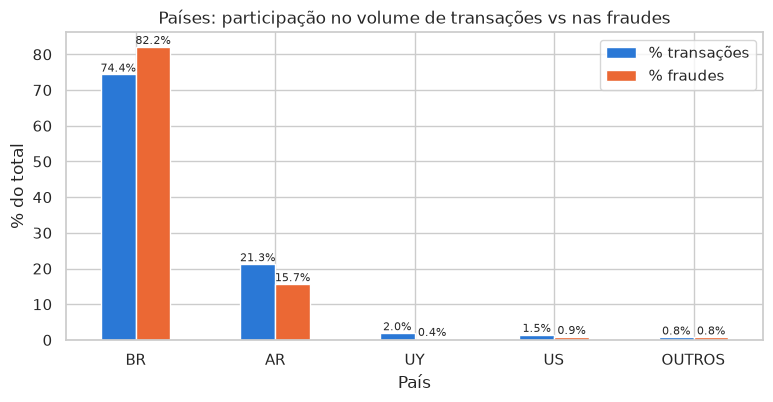

,transacoes,fraudes,% transações,% fraudes
pais,,,,
BR,111628,6162,74.4,82.2
AR,31964,1179,21.3,15.7
UY,2967,29,2.0,0.4
US,2273,70,1.5,0.9
OUTROS,1168,60,0.8,0.8


In [27]:
PAISES_PRINCIPAIS = ["BR", "AR", "UY", "US"]

# Países principais + OUTROS (inclui os demais países e os nulos de g)
df["pais"] = df["g"].where(df["g"].isin(PAISES_PRINCIPAIS), "OUTROS")

paises = df.groupby("pais").agg(transacoes=("fraude", "size"), fraudes=("fraude", "sum"))
paises["% transações"] = paises["transacoes"] / paises["transacoes"].sum() * 100
paises["% fraudes"] = paises["fraudes"] / paises["fraudes"].sum() * 100
paises = paises.sort_values("transacoes", ascending=False)

ax = paises[["% transações", "% fraudes"]].plot(kind="bar", color=[LEGIT_COLOR, FRAUD_COLOR], figsize=(9, 4))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8)
ax.set(title="Países: participação no volume de transações vs nas fraudes", xlabel="País", ylabel="% do total")
plt.xticks(rotation=0)
plt.show()

paises.round(1)

BR concentra 74% das transações, mas 82% das fraudes: proporcionalmente, mais fraude que os outros países. AR tem menos fraude do que o seu volume (21% das transações, 16% das fraudes), e UY tem bem menos (2% vs 0,4%). Juntos, BR e AR respondem por ~98% das fraudes, mas os demais países continuam no modelo, agrupados em OUTROS, porque o modelo vai pontuar transações de todos eles.

### Verificar distribuição de fraude por categoria nas variáveis categóricas

   mean    size
a              
1  9.42    4195
2  7.78   14378
3  9.06    2848
4  4.46  128579


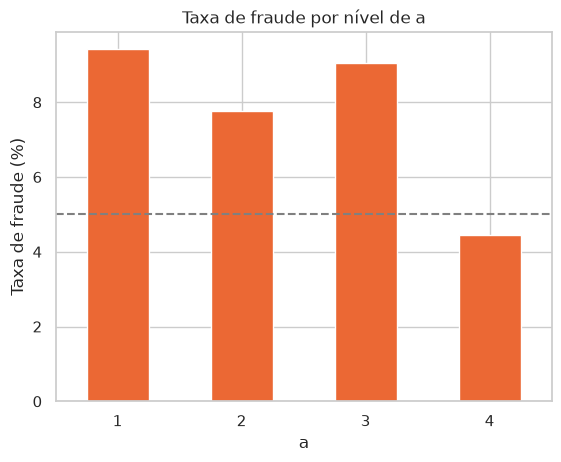

        mean    size
pais                
AR      3.69   31964
BR      5.52  111628
OUTROS  5.14    1168
US      3.08    2273
UY      0.98    2967


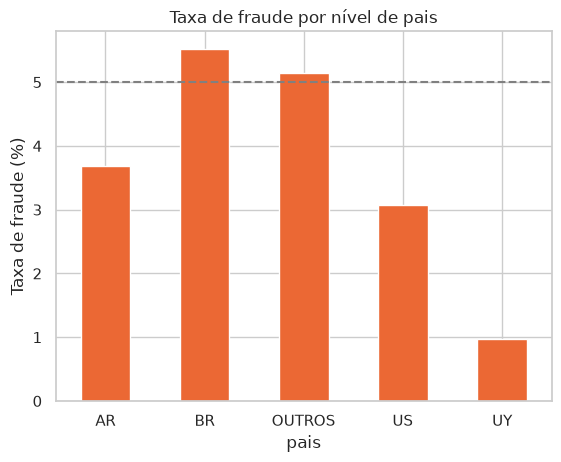

    mean    size
n               
0  16.11   14647
1   3.80  135353


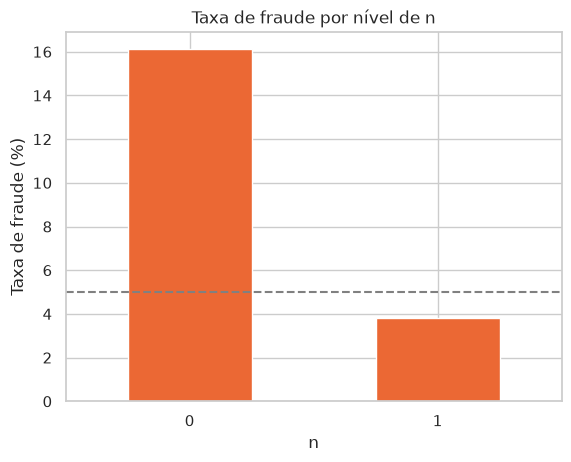

       mean    size
o                  
N     21.75   17052
Y      6.45   24091
nulo   2.05  108857


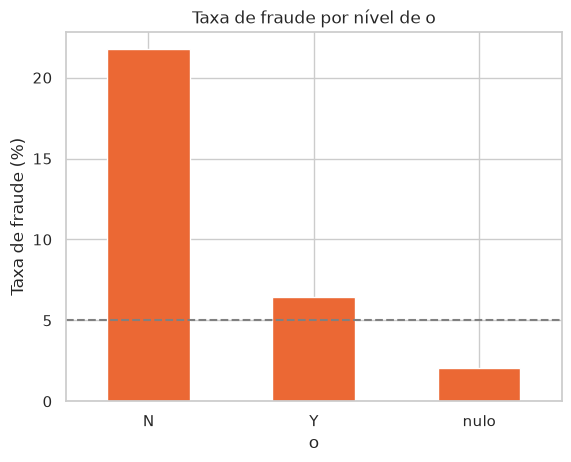

   mean   size
p             
N  7.60  66871
Y  2.91  83129


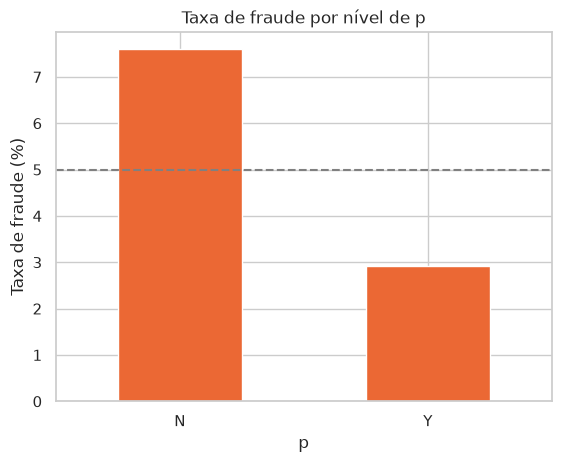

In [28]:
for col in ["a", "pais", "n", "o", "p"]:
    levels = df[col].fillna("nulo").astype(str)

    table = df.groupby(levels)["fraude"].agg(["mean", "size"])
    table["mean"] *= 100
    print(table.round(2))

    ax = table["mean"].plot(kind="bar", color=FRAUD_COLOR)
    ax.axhline(5, color="gray", linestyle="--")  # média geral
    ax.set(title=f"Taxa de fraude por nível de {col}", xlabel=col, ylabel="Taxa de fraude (%)")
    plt.xticks(rotation=0)
    plt.show()

### Resumo por coluna
Uma linha por coluna: tipo, decisão (com o tratamento de nulos quando houver) e % de nulos.
Regra: manter por padrão; remover só o que vaza informação, identifica a linha ou não tem sinal relevante.

In [54]:
summary = pd.DataFrame([
    # coluna,      tipo,          decisão
    ("k",          "numérica",    "drop: única por linha, sem sinal (KS 0,01)"),
    ("c",          "numérica",    "drop: sinal fraco (KS 0,05); nulo idêntico ao de b"),
    ("e",          "numérica",    "drop: sinal fraco (KS 0,08), sem padrão claro nos decis"),
    ("score",      "champion",    "fora do modelo, só avaliação (modelo atual)"),
    ("f",          "numérica",    "manter (melhor sinal)"),
    ("l",          "numérica",    "manter (melhor sinal)"),
    ("m",          "numérica",    "manter"),
    ("d",          "numérica",    "manter"),
    ("b",          "numérica",    "manter com nulos"),
    ("h",          "numérica",    "manter"),
    ("monto",      "numérica",    "manter"),
    ("a",          "categórica",  "manter"),
    ("n",          "categórica",  "manter"),
    ("o",          "categórica",  "manter; nulo vira categoria (grupo de menor risco)"),
    ("p",          "categórica",  "manter"),
    ("g",          "categórica",  "agrupar em pais: BR, AR, UY, US e OUTROS (demais países e nulos)"),
    ("j",          "categórica",  "transformar: frequência da categoria (Step 4, após o split)"),
    ("i",          "texto",       "drop: seria uma boa feature para um modelo de linguagem como transformers, mas não traz explicabilidade para um modelo de Boost"),
    ("fecha",      "data",        "transformar: hora do dia; também define o split"),
], columns=["coluna", "tipo", "decisao"]).set_index("coluna")

summary["pct_nulos"] = (df[summary.index].isnull().mean() * 100).round(2)
summary

,tipo,decisao,pct_nulos
coluna,,,
k,numérica,"drop: única por linha, sem sinal (KS 0,01)",0.00
c,numérica,"drop: sinal fraco (KS 0,05); nulo idêntico ao ...",8.66
e,numérica,"drop: sinal fraco (KS 0,08), sem padrão claro ...",0.00
score,Incumbent,"fora do modelo, só avaliação",0.00
f,numérica,manter (melhor sinal),0.01
l,numérica,manter (melhor sinal),0.01
m,numérica,manter,0.24
d,numérica,manter,0.24
b,numérica,manter com nulos,8.66


A escolha do LightGBM como Challenger se manterá porque a EDA mostrou sinais não lineares (o salto no topo de b e monto, o pico de fraude na madrugada), nulos informativos e variáveis categóricas, que o boosting trata nativamente. A regressão logística entra como baseline: se o LightGBM não a superar com folga, a complexidade extra não se justifica.